In [24]:
pip install prophet pandas numpy joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd


def generate_synthetic_df(
    n_groups: int = 100,
    start_date: str = "2022-01-01",
    n_years: int = 4,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Генерирует синтетические daily time series:
    - восходящий тренд
    - multiplicative weekly + yearly сезонности
    - шум пропорционален уровню

    Output columns:
      group_id | date | amount
    """
    rng = np.random.default_rng(seed)
    n_days = int(365 * n_years)
    dates = pd.date_range(start=start_date, periods=n_days, freq="D")

    rows = []

    for g in range(n_groups):
        group_id = f"group_{g}"

        # базовый уровень
        base_level = rng.uniform(50, 500)

        # годовой рост (10–60%)
        annual_growth = rng.uniform(0.10, 0.90)
        daily_growth = (1.0 + annual_growth) ** (1.0 / 365.0)

        # амплитуды сезонностей
        weekly_amp = rng.uniform(0.05, 0.25)
        yearly_amp = rng.uniform(0.10, 0.40)

        for i, d in enumerate(dates):
            # тренд
            trend = base_level * (daily_growth ** i)

            # weekly seasonality
            weekly = 1.0 + weekly_amp * np.sin(2 * np.pi * d.dayofweek / 7)

            # yearly seasonality
            yearly = 1.0 + yearly_amp * np.sin(2 * np.pi * d.dayofyear / 365)

            # шум (мультипликативный)
            noise = rng.normal(loc=1.0, scale=0.12)

            amount = trend * weekly * yearly * noise
            amount = max(0.0, float(amount))

            rows.append(
                {
                    "group_id": group_id,
                    "date": d,
                    "amount": amount,
                }
            )

    df = pd.DataFrame(rows)
    return df


In [3]:
df = generate_synthetic_df(
    n_groups=50,   # начни с 30–50
    n_years=4,
)

print(df.head())
print(df.tail())
print(df.dtypes)
print(df.groupby("group_id").size().describe())


  group_id       date      amount
0  group_0 2022-01-01  240.369623
1  group_0 2022-01-02  281.035157
2  group_0 2022-01-03  411.683819
3  group_0 2022-01-04  460.558568
4  group_0 2022-01-05  498.274357
       group_id       date      amount
72995  group_49 2025-12-26  578.711735
72996  group_49 2025-12-27  382.224874
72997  group_49 2025-12-28  401.706704
72998  group_49 2025-12-29  512.187585
72999  group_49 2025-12-30  853.226450
group_id            object
date        datetime64[ns]
amount             float64
dtype: object
count      50.0
mean     1460.0
std         0.0
min      1460.0
25%      1460.0
50%      1460.0
75%      1460.0
max      1460.0
dtype: float64


In [6]:
from prophet_multiseries_sum_pipeline import PipelineConfig, ProphetSumPipeline

cfg = PipelineConfig(
    horizon_days=30,
    n_folds=3,
    cps_grid=(0.01, 0.03, 0.05, 0.1, 0.2),
    sps_grid=(5.0, 10.0, 20.0),
    n_jobs=4,
)

pipe = ProphetSumPipeline(cfg)
forecasts_df, comparison_df, backtest_df = pipe.run(df)

worst = pipe.worst_groups(backtest_df, top_k=30)


10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] done processing
10:18:11 - cmdstanpy - INFO - Chain [1] start processing
10:18:11 - cmdstanpy - INFO - Chain [1]

In [7]:
print(forecasts_df.shape)
print(comparison_df.shape)
print(backtest_df.shape)

comparison_df[["ratio_future_over_past"]].describe(percentiles=[.05,.5,.95])
backtest_df[["rel_error"]].describe(percentiles=[.5,.9,.95])

(1500, 3)
(50, 8)
(50, 8)


,rel_error
count,50.000000
mean,0.033786
std,0.022242
min,0.003266
50%,0.029454
90%,0.068776
95%,0.076028
max,0.085873


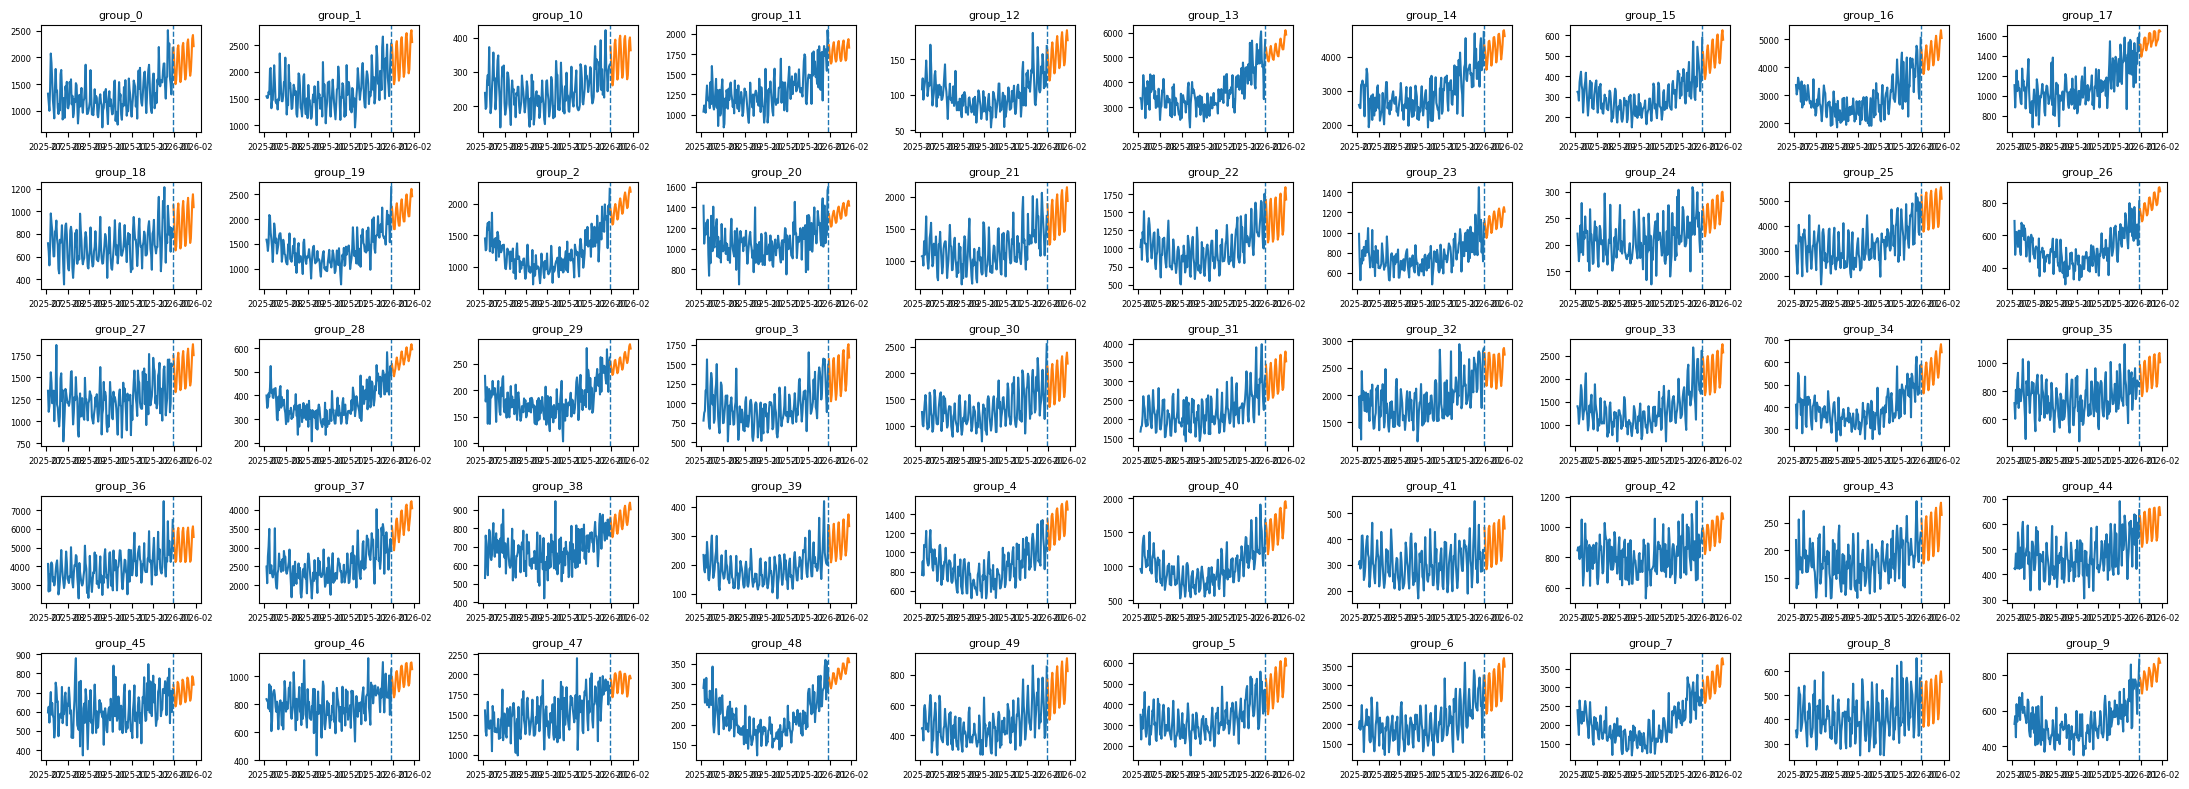

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_forecasts_grid(
    df: pd.DataFrame,
    forecasts_df: pd.DataFrame,
    group_col: str = "group_id",
    date_col: str = "date",
    y_col: str = "amount",
    yhat_col: str = "amount_pred",
    n_plots: int = 100,
    ncols: int = 10,
    history_days: int = 730,
):
    # базовая валидация
    df = df.copy()
    forecasts_df = forecasts_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    forecasts_df[date_col] = pd.to_datetime(forecasts_df[date_col])

    groups = sorted(df[group_col].unique())[:n_plots]
    n = len(groups)
    nrows = int(np.ceil(n / ncols))

    fig_w = 2.2 * ncols
    fig_h = 1.6 * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for i, gid in enumerate(groups):
        ax = axes[i]

        g_hist = df[df[group_col] == gid].sort_values(date_col)
        g_pred = forecasts_df[forecasts_df[group_col] == gid].sort_values(date_col)

        if g_hist.empty or g_pred.empty:
            ax.set_axis_off()
            continue

        # последние history_days дней истории
        cutoff = g_hist[date_col].max() - pd.Timedelta(days=history_days - 1)
        g_hist_tail = g_hist[g_hist[date_col] >= cutoff]

        last_hist_date = g_hist[date_col].max()

        ax.plot(g_hist_tail[date_col], g_hist_tail[y_col])
        ax.plot(g_pred[date_col], g_pred[yhat_col])

        # граница факт/прогноз
        ax.axvline(last_hist_date, linestyle="--", linewidth=1)

        ax.set_title(str(gid), fontsize=8)
        ax.tick_params(axis="both", labelsize=6)

    # выключаем лишние оси
    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    fig.tight_layout()
    return fig

# Пример использования:
fig = plot_forecasts_grid(df, forecasts_df, n_plots=100, ncols=10, history_days=180)
plt.show()

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def save_forecasts_pdf(
    df: pd.DataFrame,
    forecasts_df: pd.DataFrame,
    out_path: str = "forecasts_100_groups.pdf",
    group_col: str = "group_id",
    date_col: str = "date",
    y_col: str = "amount",
    yhat_col: str = "amount_pred",
    groups_limit: int = 100,
    per_page: int = 12,      # 12 = 4x3
    history_days: int = 730, # можно взять 365 для наглядности yearly
):
    df = df.copy()
    forecasts_df = forecasts_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    forecasts_df[date_col] = pd.to_datetime(forecasts_df[date_col])

    groups = sorted(df[group_col].unique())[:groups_limit]

    ncols = 3
    nrows = int(np.ceil(per_page / ncols))

    with PdfPages(out_path) as pdf:
        for start in range(0, len(groups), per_page):
            chunk = groups[start:start + per_page]

            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13, 9))
            axes = np.array(axes).reshape(-1)

            for i, gid in enumerate(chunk):
                ax = axes[i]

                g_hist = df[df[group_col] == gid].sort_values(date_col)
                g_pred = forecasts_df[forecasts_df[group_col] == gid].sort_values(date_col)

                if g_hist.empty or g_pred.empty:
                    ax.set_axis_off()
                    continue

                cutoff = g_hist[date_col].max() - pd.Timedelta(days=history_days - 1)
                g_hist_tail = g_hist[g_hist[date_col] >= cutoff]
                last_hist_date = g_hist[date_col].max()

                ax.plot(g_hist_tail[date_col], g_hist_tail[y_col], label="fact")
                ax.plot(g_pred[date_col], g_pred[yhat_col], label="forecast")
                ax.axvline(last_hist_date, linestyle="--", linewidth=1)

                ax.set_title(str(gid), fontsize=10)
                ax.tick_params(axis="both", labelsize=8)

            for j in range(i + 1, len(axes)):
                axes[j].set_axis_off()

            # легенду один раз на странице
            handles, labels = axes[0].get_legend_handles_labels()
            if handles:
                fig.legend(handles, labels, loc="upper right")

            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    print(f"Saved: {out_path}")

# Пример:
save_forecasts_pdf(df, forecasts_df, out_path="forecasts_100_groups.pdf", groups_limit=100, per_page=12, history_days=730)


Saved: forecasts_100_groups.pdf


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_groups_grid(
    df: pd.DataFrame,
    forecasts_df: pd.DataFrame,
    group_ids: list,
    history_days: int = 365,
    ncols: int = 5,
    suptitle: str | None = None,
):
    """
    Рисует сетку графиков для списка group_id:
      - факт за последние history_days
      - прогноз на горизонте (из forecasts_df)
      - пунктиром граница факт/прогноз

    Ожидаемые колонки:
      df: group_id, date, amount
      forecasts_df: group_id, date, amount_pred
    """
    if not group_ids:
        raise ValueError("group_ids is empty")

    df = df.copy()
    forecasts_df = forecasts_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    forecasts_df["date"] = pd.to_datetime(forecasts_df["date"])

    n = len(group_ids)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3.2 * ncols, 2.1 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, gid in enumerate(group_ids):
        ax = axes[i]

        g = df[df["group_id"] == gid].sort_values("date")
        f = forecasts_df[forecasts_df["group_id"] == gid].sort_values("date")

        if g.empty or f.empty:
            ax.set_axis_off()
            continue

        cutoff = g["date"].max() - pd.Timedelta(days=history_days - 1)
        g_tail = g[g["date"] >= cutoff]
        split_date = g["date"].max()

        ax.plot(g_tail["date"], g_tail["amount"], linewidth=1)
        ax.plot(f["date"], f["amount_pred"], linewidth=1)
        ax.axvline(split_date, linestyle="--", linewidth=1)

        ax.set_title(str(gid), fontsize=9)
        ax.tick_params(axis="both", labelsize=7)

    # выключаем лишние оси
    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)

    fig.tight_layout()
    plt.show()


def plot_top_k_groups(
    df: pd.DataFrame,
    forecasts_df: pd.DataFrame,
    backtest_df: pd.DataFrame | None = None,
    comparison_df: pd.DataFrame | None = None,
    k_worst: int = 10,
    k_best_diff: int = 10,
    k_bottom_diff: int = 10,
    k_random: int = 0,
    history_days: int = 365,
    ncols: int = 5,
    seed: int = 42,
):
    """
    Собирает group_id из backtest/comparison и рисует сетки.

    Требуемые колонки:
      backtest_df: group_id, rel_error
      comparison_df: group_id, diff_future_minus_past
    """
    rng = np.random.default_rng(seed)

    all_groups = sorted(df["group_id"].unique().tolist())

    def _safe_take(series, k, ascending):
        if series is None or k <= 0:
            return []
        s = series.dropna()
        if s.empty:
            return []
        s = s.sort_values(ascending=ascending)
        return s.head(k).index.tolist()

    # worst by backtest rel_error (descending)
    worst_ids = []
    if backtest_df is not None and not backtest_df.empty and k_worst > 0:
        bt = backtest_df.dropna(subset=["group_id", "rel_error"]).copy()
        bt = bt.sort_values("rel_error", ascending=False)
        worst_ids = bt["group_id"].head(k_worst).tolist()

    # best & bottom by diff
    best_ids = []
    bottom_ids = []
    if comparison_df is not None and not comparison_df.empty:
        cmp = comparison_df.dropna(subset=["group_id", "diff_future_minus_past"]).copy()
        if k_best_diff > 0:
            best_ids = cmp.sort_values("diff_future_minus_past", ascending=False)["group_id"].head(k_best_diff).tolist()
        if k_bottom_diff > 0:
            bottom_ids = cmp.sort_values("diff_future_minus_past", ascending=True)["group_id"].head(k_bottom_diff).tolist()

    # random
    random_ids = []
    if k_random > 0:
        random_ids = rng.choice(all_groups, size=min(k_random, len(all_groups)), replace=False).tolist()

    # Рисуем отдельными страницами (чтобы было читаемо)
    if worst_ids:
        plot_groups_grid(
            df, forecasts_df, worst_ids,
            history_days=history_days, ncols=ncols,
            suptitle=f"WORST by backtest rel_error (top {len(worst_ids)})"
        )

    if best_ids:
        plot_groups_grid(
            df, forecasts_df, best_ids,
            history_days=history_days, ncols=ncols,
            suptitle=f"TOP growth by diff_future_minus_past (top {len(best_ids)})"
        )

    if bottom_ids:
        plot_groups_grid(
            df, forecasts_df, bottom_ids,
            history_days=history_days, ncols=ncols,
            suptitle=f"BOTTOM growth by diff_future_minus_past (top {len(bottom_ids)})"
        )

    if random_ids:
        plot_groups_grid(
            df, forecasts_df, random_ids,
            history_days=history_days, ncols=ncols,
            suptitle=f"RANDOM groups (n={len(random_ids)})"
        )


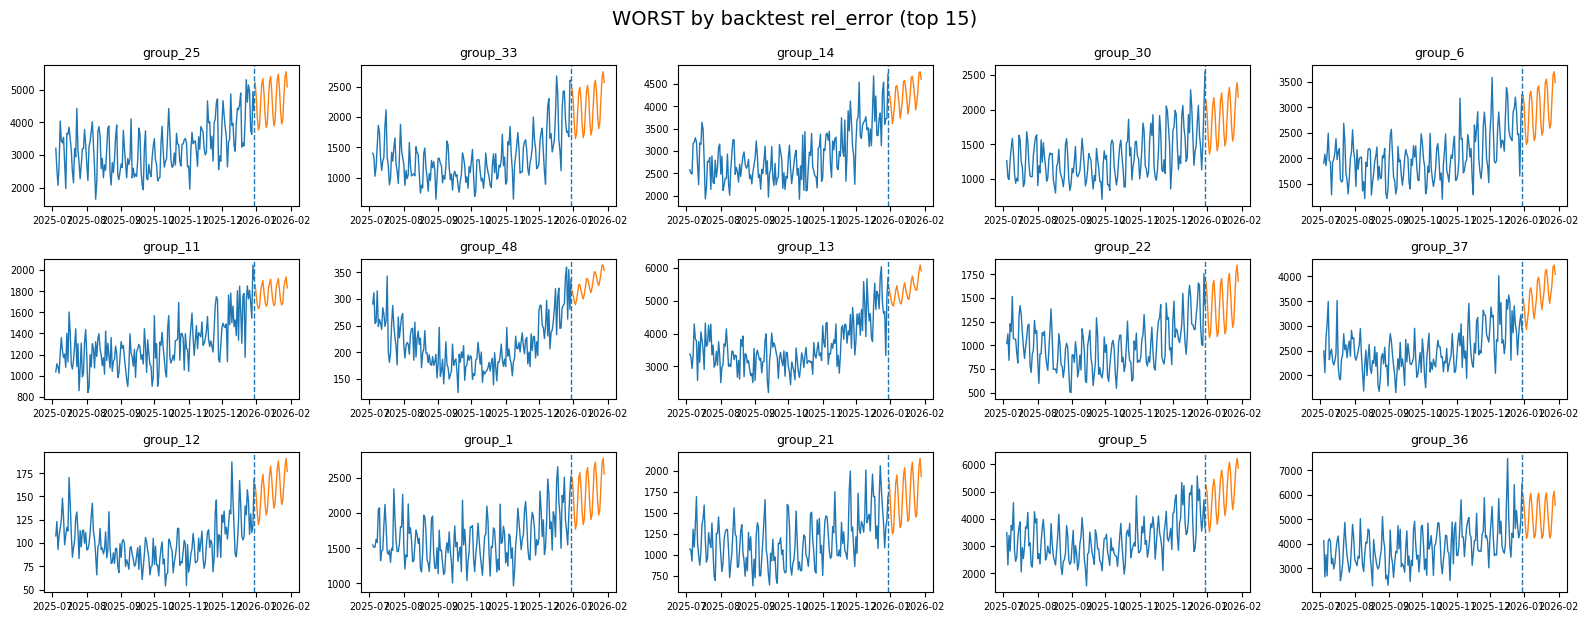

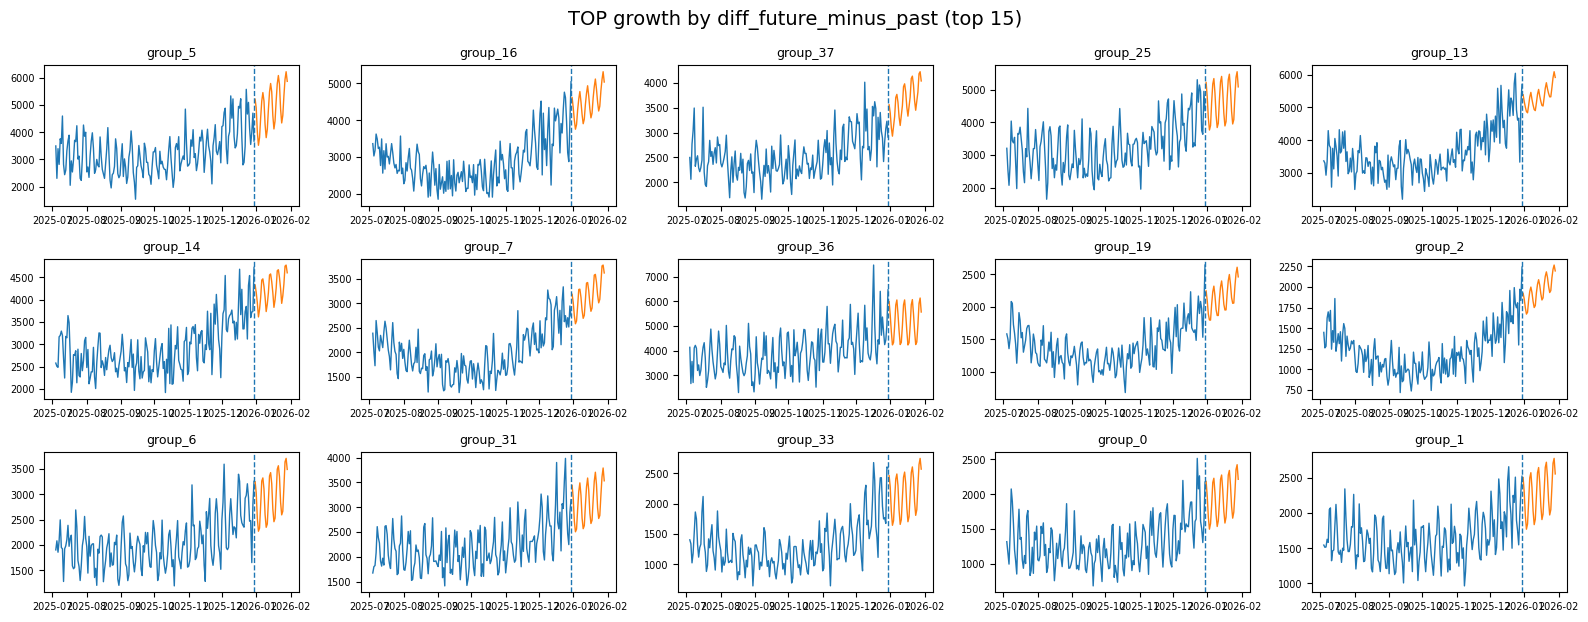

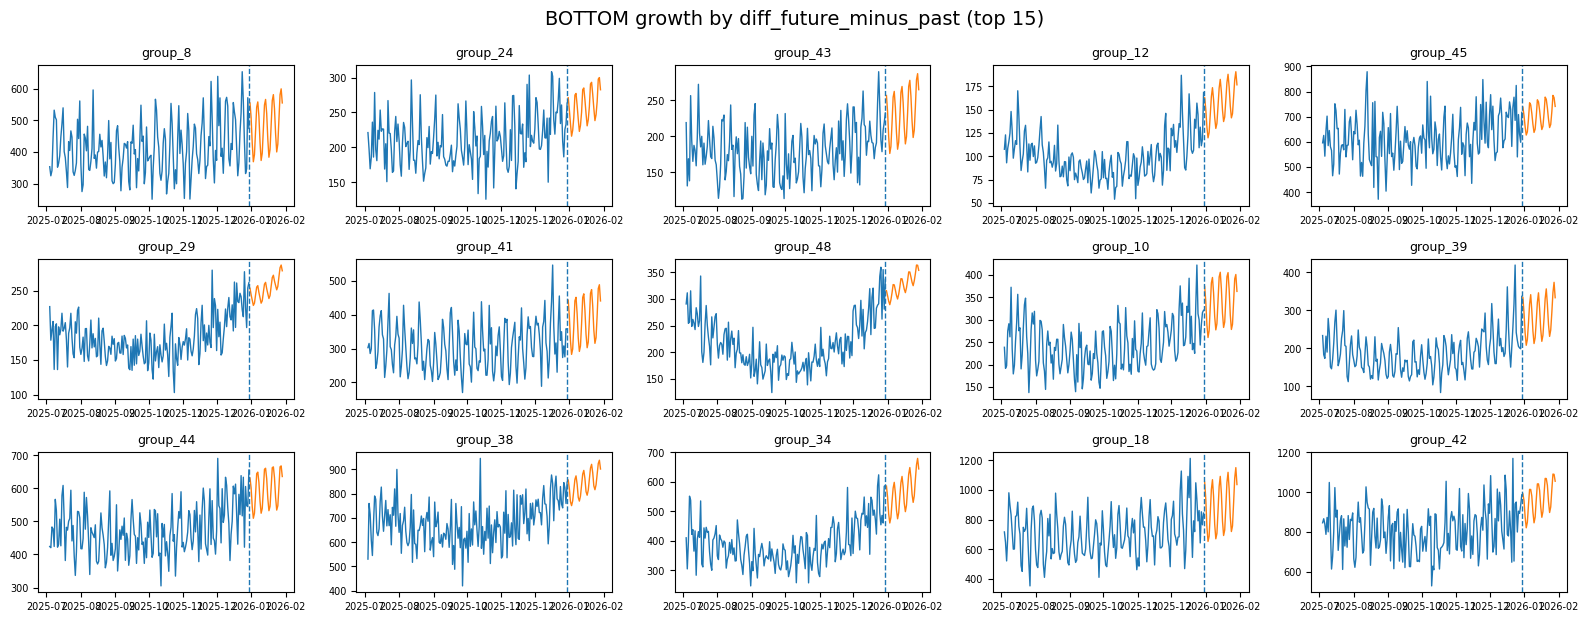

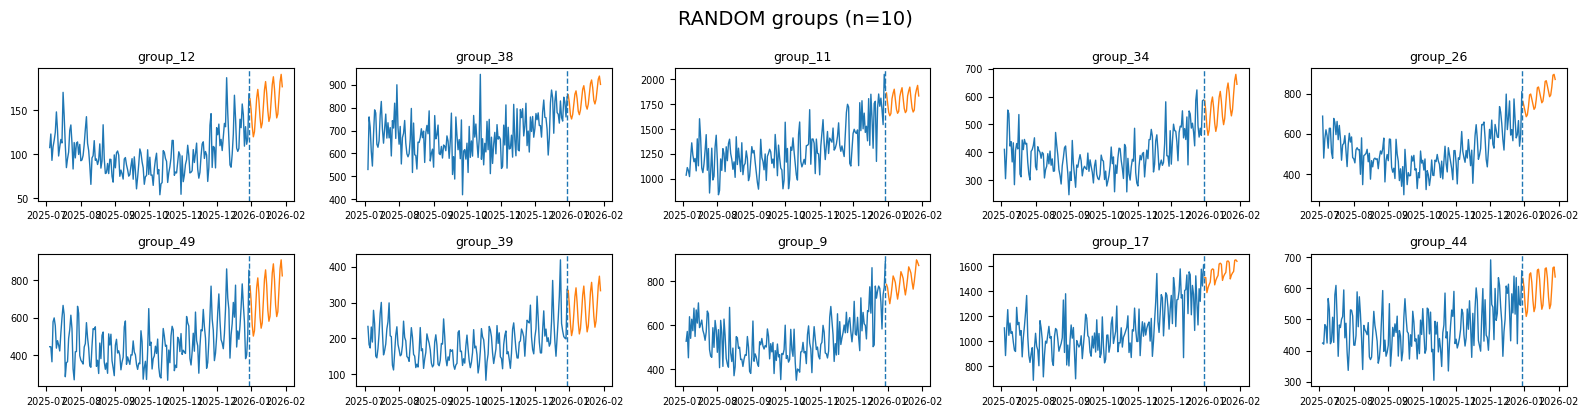

In [38]:
plot_top_k_groups(
    df=df,
    forecasts_df=forecasts_df,
    backtest_df=backtest_df,
    comparison_df=comparison_df,
    k_worst=15,
    k_best_diff=15,
    k_bottom_diff=15,
    k_random=10,
    history_days=180,
    ncols=5,
)
